In [1]:
# %pip install --quiet --upgrade pip
# %pip install numpy --quiet
# %pip install Pandas --quiet
# %pip install sklearn --quiet
# %pip install ipywidgets --quiet

# Horse Racing Results Predictor using Linear regression

Predict `TodaysRaceCard.csv` using simple linear regression techniques by determining predicted **speed** of a horse in a given race based on its previous performance.

Data used here is derived from the features extracted by the [Feature Analysis](https://github.com/LeeSanderson/RacingData/blob/main/Data/FeatureAnalysis.ipynb) notebook.


## Build the model


In [2]:
import numpy as np
import pandas as pd
import math
from abc import ABC, abstractmethod
from datetime import datetime, date

from race_analytics.utils.data_transforms import (
    surface_categories,
    going_categories,
    race_type_categories,
    encode_surfaces,
    encode_going,
    encode_race_type,
)
from race_analytics.utils.data_analysis import calculateHorsesPerRace

In [3]:
races = pd.read_csv("Race_Features.csv")
races["Off"] = pd.to_datetime(races["Off"], format="%Y-%m-%d %H:%M:%S")
races.columns

Index(['RaceId', 'CourseId', 'RaceType', 'Off', 'DecimalOdds',
       'OfficialRating', 'RacingPostRating', 'TopSpeedRating',
       'DistanceInMeters', 'Going', 'Surface', 'HorseId', 'HorseName',
       'JockeyId', 'JockeyName', 'TrainerId', 'TrainerName', 'Age', 'HeadGear',
       'RaceCardNumber', 'StallNumber', 'WeightInPounds', 'FinishingPosition',
       'OverallBeatenDistance', 'RaceTimeInSeconds', 'Wins',
       'Surface_AllWeather', 'Surface_Dirt', 'Surface_Turf', 'Going_Firm',
       'Going_Good', 'Going_Good_To_Firm', 'Going_Good_To_Soft', 'Going_Heavy',
       'Going_Soft', 'RaceType_Flat', 'RaceType_Hurdle', 'RaceType_Other',
       'RaceType_SteepleChase', 'Speed', 'HorseCount', 'KnownHorseAndJockey',
       'NumberOfPriorRaces', 'LastRaceGoing', 'LastRaceSurface',
       'LastRaceDistanceInMeters', 'LastRaceWeightInPounds', 'LastRaceSpeed',
       'DaysRested', 'LastRaceDecimalOdds', 'LastRaceOfficialRating',
       'LastRaceRacingPostRating', 'LastRaceTopSpeedRating',
 

In [4]:
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

race_info = [
    "RaceId",
    "CourseId",
    "Off",
    "HorseId",
    "HorseName",
    "HorseCount",
    "JockeyId",
    "JockeyName",
    "DecimalOdds",
    "Wins",
    "FinishingPosition",
]
predictors = [
    "DistanceInMeters",
    "WeightInPounds",
    "Surface_AllWeather",
    "Surface_Dirt",
    "Surface_Turf",
    "Going_Firm",
    "Going_Good",
    "Going_Good_To_Firm",
    "Going_Good_To_Soft",
    "Going_Heavy",
    "Going_Soft",
    "RaceType_Flat",
    "RaceType_Hurdle",
    "RaceType_Other",
    "RaceType_SteepleChase",
    "LastRaceDistanceInMeters",
    "LastRaceWeightInPounds",
    "LastRaceSpeed",
    "DaysRested",
    "LastRaceAvgRelFinishingPosition",
    "LastRaceSurface_AllWeather",
    "LastRaceSurface_Dirt",
    "LastRaceSurface_Turf",
    "LastRaceGoing_Good",
    "LastRaceGoing_Good_To_Soft",
    "LastRaceGoing_Soft",
    "LastRaceGoing_Good_To_Firm",
    "LastRaceGoing_Firm",
    "LastRaceGoing_Heavy",
    "LastRaceRaceType_Other",
    "LastRaceRaceType_Hurdle",
    "LastRaceRaceType_SteepleChase",
    "LastRaceRaceType_Flat",
    "JockeyNumberOfPriorRaces",
    "DaysSinceJockeyLastRaced",
    "JockeyWinPercentage",
    "JockeyTop3Percentage",
    "JockeyAvgRelFinishingPosition",
]
prediction = ["Speed"]

train = races[race_info + predictors + prediction].dropna().copy()

In [5]:
# Cap rested days
train.loc[train["DaysRested"] > 10, "DaysRested"] = 10
train.loc[train["DaysSinceJockeyLastRaced"] > 10, "DaysSinceJockeyLastRaced"] = 10

# Cap prior races
# train.loc[train["JockeyNumberOfPriorRaces"] > 400] = 400 (negative effect)

In [6]:
# Now that we've dropped any rows with na values, calculate which races in which we can predict the speed for all horses.
train = train.drop("PredictableHorseCount", axis=1, errors="ignore")
groups = (
    train.groupby(["RaceId"])["HorseId"]
    .agg(["count"])
    .rename(columns={"count": "PredictableHorseCount"})
)
train = pd.merge(train, groups, how="left", on=["RaceId"])

# 50% of races have 11 horse, 25% have 8 or less, 14% have 6 or less, 9% have 5 or less. Fewer horses should be more predictable
all_races_count = len(races["RaceId"].unique())
all_predictable = (
    train[
        (train["HorseCount"] == train["PredictableHorseCount"])
        & (train["HorseCount"] <= 5)
    ]["RaceId"]
    .unique()
    .tolist()
)
all_predictable_count = len(all_predictable)
print(
    f"Possible predictable races = {all_predictable_count} out of {all_races_count} ({all_predictable_count * 100 / all_races_count}%)"
)

Possible predictable races = 609 out of 8747 (6.962387104149994%)


In [7]:
from sklearn.model_selection import train_test_split

_, test_race_ids = train_test_split(all_predictable, test_size=0.2, random_state=42)

test = train[train["RaceId"].isin(test_race_ids)]
train = train[train["RaceId"].isin(test_race_ids) == False]

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a pipeline that includes feature scaling and linear regression
model = make_pipeline(
    StandardScaler(), PolynomialFeatures(degree=2, interaction_only=False), Ridge()
)

In [9]:
inputs = train[predictors]
targets = train[prediction[0]].values

In [10]:
model.fit(inputs, targets)
test_inputs = test[predictors]
predictions = model.predict(test_inputs)

In [11]:
test_with_predictions = test.copy()
test_with_predictions["PredictedSpeed"] = predictions

In [12]:
test_with_predictions["PredictedRank"] = test_with_predictions.groupby("RaceId")[
    "PredictedSpeed"
].rank(method="dense", ascending=False)

In [13]:
correct_winners = test_with_predictions[
    (test_with_predictions["FinishingPosition"] == 1)
    & (test_with_predictions["PredictedRank"] == 1)
]

correct_winners_count = len(correct_winners)
incorrect_winners_count = len(
    test_with_predictions[
        (test_with_predictions["FinishingPosition"] == 1)
        & (test_with_predictions["PredictedRank"] != 1)
    ]
)

winnings = correct_winners["DecimalOdds"].sum()
win_percentage = (
    100.0 * correct_winners_count / (correct_winners_count + incorrect_winners_count)
)

print(
    f"Correct winners {correct_winners_count}, Incorrect winners {incorrect_winners_count}"
)
print(f"Win percentage {win_percentage}")
print(
    f"Winnings {winnings}, losses {incorrect_winners_count}, diff  {winnings - incorrect_winners_count}"
)

if win_percentage < 20:
    raise ValueError("Prediction rate too low")

Correct winners 42, Incorrect winners 80
Win percentage 34.42622950819672
Winnings 162.38558663558663, losses 80, diff  82.38558663558663


## Predictions


In [14]:
todays_races = pd.read_csv("TodaysRaceCards.csv")
todays_races["Off"] = pd.to_datetime(todays_races["Off"], format="%m/%d/%Y %H:%M:%S")
todays_races.columns

Index(['RaceId', 'RaceName', 'CourseId', 'CourseName', 'Off', 'RaceType',
       'Class', 'Pattern', 'RatingBand', 'AgeBand', 'SexRestriction',
       'Distance', 'DistanceInFurlongs', 'DistanceInMeters', 'DistanceInYards',
       'Going', 'Surface', 'HorseId', 'HorseName', 'JockeyId', 'JockeyName',
       'TrainerId', 'TrainerName', 'Age', 'HeadGear', 'RaceCardNumber',
       'StallNumber', 'Weight', 'WeightInPounds', 'FractionalOdds',
       'DecimalOdds', 'OfficialRating', 'RacingPostRating', 'TopSpeedRating'],
      dtype='object')

### Expand categorical variables


In [15]:
todays_races = encode_surfaces(todays_races)
todays_races[surface_categories].value_counts()

Surface_AllWeather  Surface_Dirt  Surface_Turf
0.0                 0.0           1.0             379
1.0                 0.0           0.0              88
Name: count, dtype: int64

In [16]:
todays_races = encode_going(todays_races)
todays_races[going_categories].value_counts()

Going_Good  Going_Good_To_Soft  Going_Soft  Going_Good_To_Firm  Going_Firm  Going_Heavy
0.0         1.0                 0.0         0.0                 0.0         0.0            217
1.0         0.0                 0.0         0.0                 0.0         0.0            183
0.0         0.0                 0.0         1.0                 0.0         0.0             67
Name: count, dtype: int64

In [17]:
todays_races = encode_race_type(todays_races)
todays_races[race_type_categories].value_counts()

RaceType_Other  RaceType_Hurdle  RaceType_SteepleChase  RaceType_Flat
1.0             0.0              0.0                    0.0              390
0.0             1.0              0.0                    0.0               57
                0.0              1.0                    0.0               20
Name: count, dtype: int64

In [18]:
todays_races.columns

Index(['RaceId', 'RaceName', 'CourseId', 'CourseName', 'Off', 'RaceType',
       'Class', 'Pattern', 'RatingBand', 'AgeBand', 'SexRestriction',
       'Distance', 'DistanceInFurlongs', 'DistanceInMeters', 'DistanceInYards',
       'Going', 'Surface', 'HorseId', 'HorseName', 'JockeyId', 'JockeyName',
       'TrainerId', 'TrainerName', 'Age', 'HeadGear', 'RaceCardNumber',
       'StallNumber', 'Weight', 'WeightInPounds', 'FractionalOdds',
       'DecimalOdds', 'OfficialRating', 'RacingPostRating', 'TopSpeedRating',
       'Surface_AllWeather', 'Surface_Turf', 'Surface_Dirt', 'Going_Good',
       'Going_Good_To_Firm', 'Going_Good_To_Soft', 'Going_Soft', 'Going_Firm',
       'Going_Heavy', 'RaceType_Hurdle', 'RaceType_Other',
       'RaceType_SteepleChase', 'RaceType_Flat'],
      dtype='object')

### Load horse stats


In [19]:
horse_stats = pd.read_csv("Horse_Stats.csv")
horse_stats["LastOff"] = pd.to_datetime(
    horse_stats["LastOff"], format="%Y-%m-%d %H:%M:%S"
)
horse_stats.columns

Index(['HorseId', 'LastOff', 'LastRaceDistanceInMeters',
       'LastRaceWeightInPounds', 'LastRaceAvgRelFinishingPosition',
       'LastRaceSurface_AllWeather', 'LastRaceSurface_Dirt',
       'LastRaceSurface_Turf', 'LastRaceGoing_Firm', 'LastRaceGoing_Good',
       'LastRaceGoing_Good_To_Firm', 'LastRaceGoing_Good_To_Soft',
       'LastRaceGoing_Heavy', 'LastRaceGoing_Soft', 'LastRaceRaceType_Flat',
       'LastRaceRaceType_Hurdle', 'LastRaceRaceType_Other',
       'LastRaceRaceType_SteepleChase', 'LastRaceSpeed'],
      dtype='object')

In [20]:
todays_races = pd.merge(todays_races, horse_stats, how="left", on=["HorseId"])

In [21]:
today = np.datetime64(datetime.today())
one_day = np.timedelta64(1, "D")
todays_races["DaysRested"] = np.ceil((today - todays_races["LastOff"]) / one_day)
todays_races.loc[todays_races["DaysRested"] > 10, "DaysRested"] = 10
todays_races = todays_races.drop("LastOff", axis=1, errors="ignore")

In [22]:
todays_races = calculateHorsesPerRace(todays_races)
todays_races["HorseCount"] = todays_races["HorseCount"].astype(int)

### Load jockey stats


In [23]:
jockey_stats = pd.read_csv("Jockey_Stats.csv")
jockey_stats["LastOff"] = pd.to_datetime(
    jockey_stats["LastOff"], format="%Y-%m-%d %H:%M:%S"
)
jockey_stats.columns

Index(['JockeyId', 'LastOff', 'JockeyNumberOfPriorRaces',
       'JockeyWinPercentage', 'JockeyTop3Percentage',
       'JockeyAvgRelFinishingPosition'],
      dtype='object')

In [24]:
todays_races = pd.merge(todays_races, jockey_stats, how="left", on=["JockeyId"])

In [25]:
todays_races["DaysSinceJockeyLastRaced"] = np.ceil(
    (today - todays_races["LastOff"]) / one_day
)
todays_races.loc[
    todays_races["DaysSinceJockeyLastRaced"] > 10, "DaysSinceJockeyLastRaced"
] = 10
todays_races = todays_races.drop("LastOff", axis=1, errors="ignore")

### Eliminate races that cannot be reliably predicted


In [26]:
todays_races.columns

Index(['RaceId', 'RaceName', 'CourseId', 'CourseName', 'Off', 'RaceType',
       'Class', 'Pattern', 'RatingBand', 'AgeBand', 'SexRestriction',
       'Distance', 'DistanceInFurlongs', 'DistanceInMeters', 'DistanceInYards',
       'Going', 'Surface', 'HorseId', 'HorseName', 'JockeyId', 'JockeyName',
       'TrainerId', 'TrainerName', 'Age', 'HeadGear', 'RaceCardNumber',
       'StallNumber', 'Weight', 'WeightInPounds', 'FractionalOdds',
       'DecimalOdds', 'OfficialRating', 'RacingPostRating', 'TopSpeedRating',
       'Surface_AllWeather', 'Surface_Turf', 'Surface_Dirt', 'Going_Good',
       'Going_Good_To_Firm', 'Going_Good_To_Soft', 'Going_Soft', 'Going_Firm',
       'Going_Heavy', 'RaceType_Hurdle', 'RaceType_Other',
       'RaceType_SteepleChase', 'RaceType_Flat', 'LastRaceDistanceInMeters',
       'LastRaceWeightInPounds', 'LastRaceAvgRelFinishingPosition',
       'LastRaceSurface_AllWeather', 'LastRaceSurface_Dirt',
       'LastRaceSurface_Turf', 'LastRaceGoing_Firm', 'LastRace

<Axes: >

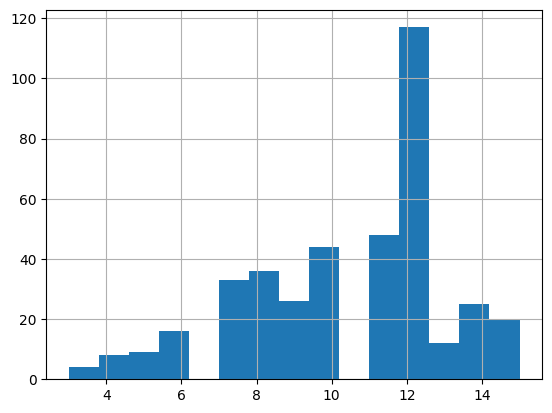

In [27]:
race_info = [
    "RaceId",
    "CourseId",
    "CourseName",
    "Off",
    "HorseId",
    "HorseName",
    "HorseCount",
    "JockeyId",
    "JockeyName",
]

races_to_predict = todays_races[race_info + predictors].dropna().copy()

max_horses_in_race = races_to_predict["HorseCount"].max()
races_to_predict["HorseCount"].hist(bins=max_horses_in_race)

<Axes: >

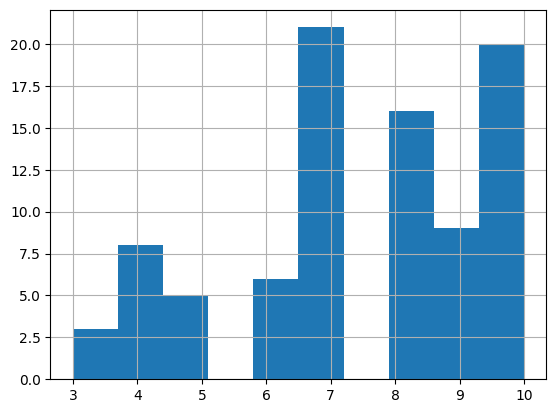

In [28]:
if len(races_to_predict) > 0:
    # Now that we've dropped any rows with na values, calculate which races in which we can predict the speed for all horses.
    races_to_predict = races_to_predict.drop(
        "PredictableHorseCount", axis=1, errors="ignore"
    )
    groups = (
        races_to_predict.groupby(["RaceId"])["HorseId"]
        .agg(["count"])
        .rename(columns={"count": "PredictableHorseCount"})
    )
    races_to_predict = pd.merge(races_to_predict, groups, how="left", on=["RaceId"])
    races_to_predict = races_to_predict[
        (races_to_predict["HorseCount"] == races_to_predict["PredictableHorseCount"])
        & (races_to_predict["HorseCount"] <= 10)
    ]

max_horses_in_race = races_to_predict["HorseCount"].max()
races_to_predict["HorseCount"].hist(bins=max_horses_in_race)

In [29]:
test_inputs = races_to_predict[predictors]
predictions = model.predict(test_inputs)
races_to_predict["PredictedSpeed"] = predictions

In [30]:
races_to_predict["PredictedRank"] = races_to_predict.groupby("RaceId")[
    "PredictedSpeed"
].rank(method="dense", ascending=False)

In [31]:
todays_predictions = races_to_predict[
    races_to_predict["PredictedRank"] == 1
].sort_values(["CourseName", "Off"])[
    ["RaceId", "CourseId", "CourseName", "Off", "HorseId", "HorseName"]
]

todays_predictions.to_csv("TodaysPredictions.csv", index=False)

todays_predictions

,RaceId,CourseId,CourseName,Off,HorseId,HorseName
80,918817,3,Ayr,2026-05-20 14:12:00,7250639,Canaria Sun
122,918815,3,Ayr,2026-05-20 15:12:00,5973427,Thunderstorm Katie
236,918816,3,Ayr,2026-05-20 17:15:00,5048133,Evelyn's Phoenix FR
112,918667,1212,Ffos Las,2026-05-20 14:50:00,5864584,Lemon Leaf IRE
194,918664,1212,Ffos Las,2026-05-20 16:20:00,5708463,Jack's Jury IRE
242,918668,1212,Ffos Las,2026-05-20 17:22:00,5326979,Jlow IRE
312,920764,184,Gowran Park,2026-05-20 19:20:00,9217607,Sparan Nua
87,918672,85,Warwick,2026-05-20 14:30:00,8940301,Royal Rocket IRE
145,918670,85,Warwick,2026-05-20 15:30:00,3309352,King Of The Story IRE
181,918671,85,Warwick,2026-05-20 16:00:00,4189542,Il Va De Soi FR


In [32]:
print(f"Generated predictions for {len(todays_predictions)} races")
print(todays_predictions[["CourseName", "Off", "HorseName"]].to_string(index=False))

Generated predictions for 13 races
 CourseName                 Off             HorseName
        Ayr 2026-05-20 14:12:00           Canaria Sun
        Ayr 2026-05-20 15:12:00    Thunderstorm Katie
        Ayr 2026-05-20 17:15:00   Evelyn's Phoenix FR
   Ffos Las 2026-05-20 14:50:00        Lemon Leaf IRE
   Ffos Las 2026-05-20 16:20:00       Jack's Jury IRE
   Ffos Las 2026-05-20 17:22:00              Jlow IRE
Gowran Park 2026-05-20 19:20:00            Sparan Nua
    Warwick 2026-05-20 14:30:00      Royal Rocket IRE
    Warwick 2026-05-20 15:30:00 King Of The Story IRE
    Warwick 2026-05-20 16:00:00       Il Va De Soi FR
    Warwick 2026-05-20 17:00:00 Kingston Sunflower FR
   Yarmouth 2026-05-20 18:40:00        Law Supreme FR
   Yarmouth 2026-05-20 19:40:00    Havana Tobouggaloo
